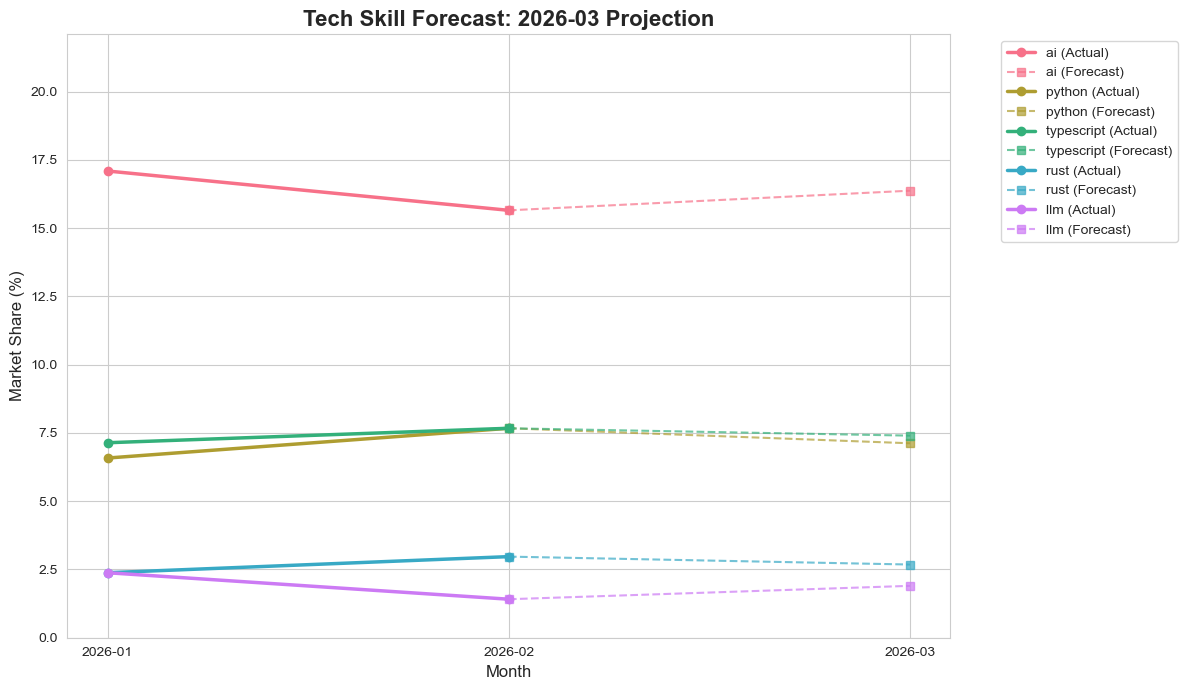

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ---- Config ----
BASE_PATH = Path.cwd().parent
ACTUALS_PATH = BASE_PATH / "data" / "analysis" / "latest_trends.csv"
FORECAST_PATH = BASE_PATH / "data" / "analysis" / "forecasts.csv"
TARGET_SKILLS = ["ai", "python", "typescript", "rust", "llm"]  # edit as needed
FIGSIZE = (12, 7)

# ---- Load ----
df_actuals = pd.read_csv(ACTUALS_PATH, usecols=["period", "skills", "market_share"])
df_forecast = pd.read_csv(FORECAST_PATH, usecols=["skill", "predicted_share"])

# Normalize for consistent matching
df_actuals["skills"] = df_actuals["skills"].str.lower()
df_forecast["skill"] = df_forecast["skill"].str.lower()

# Ensure proper time ordering
df_actuals["period"] = pd.to_datetime(df_actuals["period"], format="%Y-%m")

# Filter targets that exist in actuals
available_skills = set(df_actuals["skills"].unique())
target_skills = [s for s in TARGET_SKILLS if s in available_skills]

if not target_skills:
    raise ValueError("No target skills found in actuals. Update TARGET_SKILLS.")

# Compute next period dynamically
last_period = df_actuals["period"].max()
next_period = (last_period + pd.offsets.MonthBegin(1)).strftime("%Y-%m")
last_period_str = last_period.strftime("%Y-%m")

# ---- Plot ----
sns.set_style("whitegrid")
plt.figure(figsize=FIGSIZE)

color_map = dict(zip(target_skills, sns.color_palette("husl", len(target_skills))))

for skill in target_skills:
    skill_data = df_actuals[df_actuals["skills"] == skill].sort_values("period")
    skill_data["period_str"] = skill_data["period"].dt.strftime("%Y-%m")

    # Actuals
    plt.plot(
        skill_data["period_str"],
        skill_data["market_share"],
        marker="o",
        label=f"{skill} (Actual)",
        color=color_map[skill],
        linewidth=2.5
    )

    # Forecast (only if available)
    pred_rows = df_forecast[df_forecast["skill"] == skill]
    if not pred_rows.empty:
        last_actual_val = skill_data["market_share"].iloc[-1]
        pred_val = pred_rows["predicted_share"].iloc[0]

        plt.plot(
            [last_period_str, next_period],
            [last_actual_val, pred_val],
            linestyle="--",
            color=color_map[skill],
            marker="s",
            alpha=0.7,
            label=f"{skill} (Forecast)"
        )

plt.title(f"Tech Skill Forecast: {next_period} Projection", fontsize=16, fontweight="bold")
plt.ylabel("Market Share (%)", fontsize=12)
plt.xlabel("Month", fontsize=12)
plt.ylim(0, df_actuals["market_share"].max() + 5)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()